# XGBoost

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import time
import xgboost as xgb

from scipy.sparse import csr_matrix, hstack
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
features = pd.read_csv("/content/handcrafted_features.csv")

tfidf = joblib.load("/content/tfidf_vectorizer.pkl")
scaler = joblib.load("/content/feature_scaler.pkl")

x_train = joblib.load("/content/x_train.pkl")
x_test = joblib.load("/content/x_test.pkl")

y_train = joblib.load("/content/y_train.pkl")
y_test = joblib.load("/content/y_test.pkl")

In [3]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1274150,)
(318538,)
(1274150,)
(318538,)


In [4]:
x_train_tf = tfidf.transform(x_train)
x_test_tf = tfidf.transform(x_test)

In [5]:
print(x_train_tf.shape)
print(x_test_tf.shape)

(1274150, 50000)
(318538, 50000)


In [6]:
features_train = features.loc[x_train.index]
features_test  = features.loc[x_test.index]

In [7]:
print(features_train.shape)
print(features_test.shape)

(1274150, 19)
(318538, 19)


In [8]:

fea_tr_scaled = scaler.transform(features_train)
fea_te_scaled = scaler.transform(features_test)

In [9]:
fea_tr_sparse = csr_matrix(fea_tr_scaled)
fea_te_sparse = csr_matrix(fea_te_scaled)

In [10]:
x_train_final = hstack([
    x_train_tf, fea_tr_sparse
])
x_test_final = hstack([
    x_test_tf, fea_te_sparse
])

In [11]:
print(x_train_final.shape)
print(x_test_final.shape)

(1274150, 50019)
(318538, 50019)


## Model

In [12]:
print(xgb.__version__)

3.3.0


In [13]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.5,
    gamma=1,
    reg_alpha=1,
    reg_lambda=2,
    tree_method="hist",
    device="cpu",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [14]:
start = time.time()
xgb_model.fit(x_train_final, y_train)
end = time.time()

print(f"Training Time: {end-start:.2f} Seconds")

Training Time: 49.54 Seconds


In [17]:
start = time.time()
y_pred = xgb_model.predict(x_test_final)
end = time.time()

print(f"Prediction Time: {end-start:.2f} Seconds")

Prediction Time: 3.55 Seconds


In [18]:
y_prob = xgb_model.predict_proba(x_test_final)[:,1]
print(y_prob)

[0.66802084 0.42012957 0.44989178 ... 0.2539064  0.33331716 0.6278569 ]


Metrics

In [19]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.6880
Precision: 0.6870
Recall   : 0.6907
F1 Score : 0.6889
ROC AUC  : 0.7609


In [20]:
# Classification Report
print(f"Classification_Report: \n \n {classification_report(y_test, y_pred)}")

Classification_Report: 
 
               precision    recall  f1-score   support

           0       0.69      0.69      0.69    159267
           1       0.69      0.69      0.69    159271

    accuracy                           0.69    318538
   macro avg       0.69      0.69      0.69    318538
weighted avg       0.69      0.69      0.69    318538



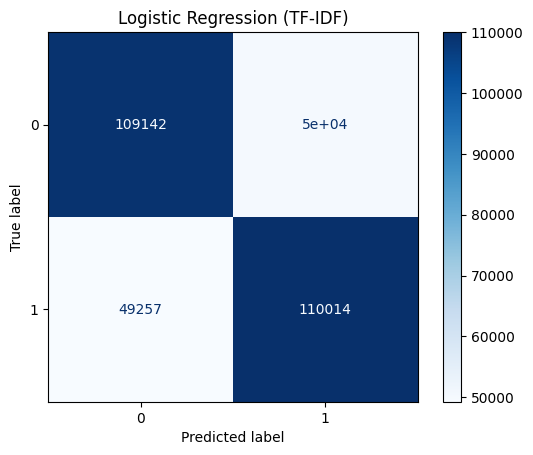

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap = "Blues"
)

plt.title("Logistic Regression (TF-IDF)")
plt.show()

In [22]:
joblib.dump(xgb_model, "xgboost_model.pkl")

['xgboost_model.pkl']